# Modelling pipeline for PPG → BGL on the clean recordings (companion to the EDA notebook)
**Scope.** This notebook builds *leak-free, participant-grouped* regression pipelines on the recordings that contain a repeating pulse (SQI ≥ 0.40, the "S_AB" subset from the EDA, n = 48) and evaluates them honestly against a **PPG-free floor**. It also runs the same pipelines on all 100 recordings for context.

**Design rules (each one answers a leakage pathway identified in the EDA).**
1. **The quality rule is fixed before modelling and uses no BGL information:** `acf_periodicity ≥ 0.40` (EDA §4.3). It is applied to whole recordings, not tuned.
2. **Grouping:** every split is by `participant_id` (repeat participants never straddle train/test). A leave-one-**day**-out check is added because signal quality and condition mix differ by collection day.
3. **Everything learned from data happens inside the training fold:** missing-value filter, imputation, scaling/rank-transform, feature selection, hyper-parameters (inner grouped CV). The only pre-defined choices are the feature lists and hyper-parameter grids.
4. **The floor is part of the model.** Each PPG model predicts the *residual* of the fasting/post-prandial mean (`is_postprandial` is the only non-PPG input), so what is measured is *what PPG adds*. Skill is reported as ΔMAE versus that floor.
5. **"Based on the analysis" without cheating.** Selecting features by their correlation with BGL on the same 48 recordings and then cross-validating is *selection bias*. Section 5 shows the size of that bias explicitly, next to the honest version (selection inside each fold).
6. **No outlier removal** (there are no BGL > 300 in this subset anyway); metrics are MAE-first.

**Requires** the EDA notebook's outputs: `ppg_reference_features_cache.csv` (extracted features) and the raw CSV (for BGL/condition/participant/day).

In [1]:
import os, sys, time, itertools, warnings
import numpy as np, pandas as pd, scipy.stats as st, matplotlib.pyplot as plt, seaborn as sns
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid", font_scale=0.95); plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SEED = 20260920
DATA_CANDIDATES = ["glucosense_dataset_2026-09-17.csv", "/mnt/user-data/uploads/glucosense_dataset_2026-09-17.csv"]
DATA_PATH = next(p for p in DATA_CANDIDATES if os.path.exists(p)); FEATURE_CACHE = "ppg_reference_features_cache.csv"
QUALITY_MIN_SQI = 0.40      # fixed a priori (EDA 4.3)
N_REP = 10                  # repeats of participant-grouped 5-fold CV
N_PERM = 100                # permutations for the null tests
print("sklearn", sklearn.__version__, "| data:", DATA_PATH)

sklearn 1.8.0 | data: glucosense_dataset_2026-09-17.csv


## 1. Data and the analysis subset

In [2]:
meta = pd.read_csv(DATA_PATH, usecols=lambda c: c != "ppg_data"); meta["rec"] = np.arange(len(meta))
F = pd.read_csv(FEATURE_CACHE); D = meta.merge(F, on="rec")
D["bgl"] = D.bgl_mgdl.astype(float); D["pp"] = (D.session_kind != "fasting").astype(int); D["date"] = pd.to_datetime(D.created_at).dt.strftime("%Y-%m-%d")
D["tier"] = pd.cut(D.acf_periodicity, [-2, .4, .7, 2], labels=["C", "B", "A"], right=False)

FEATS = ["mean_nn", "hr_mean", "sdnn", "rmssd", "cvnn", "pnn20", "pnn50", "iqr_nn", "mad_nn", "lf_power", "hf_power", "total_power_lfhf", "lf_hf", "hf_norm", "sd1", "sd2", "sd1_sd2", "sampen",
         "rise_frac", "rise_time_s", "cycle_s", "pw25", "pw50", "pw75", "area_norm", "max_upslope", "max_downslope", "slope_ratio", "t_maxslope_frac", "ac_amp_counts", "ac_over_dc_pct",
         "apg_a", "apg_b", "apg_c", "apg_d", "apg_e", "apg_b_a", "apg_c_a", "apg_d_a", "apg_e_a", "agi", "f0_hz", "spec_conc", "harm_ratio", "spec_entropy", "spec_flatness", "skew_clean", "kurt_clean"]
# Physiologically defined, one canonical feature per family (chosen by convention, not by BGL): HR, RMSSD, SDNN (PRV), pulse width, rise time (morphology), AC/DC (amplitude), APG b/a
CURATED = ["hr_mean", "rmssd", "sdnn", "pw50", "rise_time_s", "ac_over_dc_pct", "apg_b_a"]

S = D[D.acf_periodicity >= QUALITY_MIN_SQI].reset_index(drop=True); A = D.reset_index(drop=True)
print(f"analysis subset S_AB: n = {len(S)} recordings, {S.participant_id.nunique()} participants | all recordings: n = {len(A)}")
print("condition mix in S_AB:", S.session_kind.value_counts().to_dict(), "| days:", S.date.value_counts().sort_index().to_dict())
print(f"BGL in S_AB: median {S.bgl.median():.0f}, IQR {S.bgl.quantile(.25):.0f}-{S.bgl.quantile(.75):.0f}, range {S.bgl.min():.0f}-{S.bgl.max():.0f}; BGL>300 in S_AB: {(S.bgl>300).sum()}")
print("missing fraction of the 48 features in S_AB (top 8):", S[FEATS].isna().mean().sort_values(ascending=False).head(8).round(2).to_dict())

analysis subset S_AB: n = 48 recordings, 43 participants | all recordings: n = 100
condition mix in S_AB: {'fasting': 25, '2hr_post_prandial': 12, '1hr_post_prandial': 11} | days: {'2026-08-06': 2, '2026-08-27': 18, '2026-09-03': 20, '2026-09-17': 8}
BGL in S_AB: median 132, IQR 108-190, range 83-269; BGL>300 in S_AB: 0
missing fraction of the 48 features in S_AB (top 8): {'agi': 0.58, 'apg_e': 0.58, 'apg_e_a': 0.58, 'apg_d_a': 0.31, 'apg_d': 0.31, 'apg_c': 0.02, 'sampen': 0.02, 'apg_c_a': 0.02}


## 2. Pipeline components
* `MissingFilter` — drops features that are missing in more than 40 % of the *training* fold (structural missingness, EDA §5.1).
* In-fold **median imputation** and a **rank→normal transform** (robust to the skew/heavy tails found in EDA §5.2).
* `RankSelect(k)` — keeps the *k* features with largest |Spearman ρ| with the training-fold target (this is the "analysis-driven" selection, done **inside** each training fold).
* Regressors: Ridge (strong shrinkage), PLS, shallow random forest — all predict the **residual** of the training-fold condition mean (the floor).
* Hyper-parameters are chosen by an **inner** participant-grouped 3-fold CV on the training fold only.

In [3]:
class MissingFilter(BaseEstimator, TransformerMixin):
    def __init__(self, max_frac=0.4): self.max_frac = max_frac
    def fit(self, X, y=None):
        self.keep_ = np.where(np.isnan(X).mean(0) <= self.max_frac)[0]
        if len(self.keep_) == 0: self.keep_ = np.arange(X.shape[1])          # never drop everything (single-feature models)
        return self
    def transform(self, X): return X[:, self.keep_]

class RankSelect(BaseEstimator, TransformerMixin):
    """Keep the k features with the largest |Spearman rho| with y (vectorised; fitted on training data only)."""
    def __init__(self, k=5): self.k = k
    def fit(self, X, y):
        Xr = np.apply_along_axis(st.rankdata, 0, X); yr = st.rankdata(y); Xc = Xr - Xr.mean(0); yc = yr - yr.mean()
        den = np.sqrt((Xc ** 2).sum(0) * (yc ** 2).sum()); r = np.abs(np.divide((Xc * yc[:, None]).sum(0), den, out=np.zeros(X.shape[1]), where=den > 0))
        self.sel_ = np.argsort(r)[::-1][:min(self.k, X.shape[1])]; return self
    def transform(self, X): return X[:, self.sel_]

def pre(): return [("miss", MissingFilter(.4)), ("imp", SimpleImputer(strategy="median")), ("qt", QuantileTransformer(n_quantiles=20, output_distribution="normal", random_state=0))]
def gs(pipe, grid): return GridSearchCV(pipe, grid, cv=GroupKFold(3), scoring="neg_mean_absolute_error")
def make(kind):
    if kind == "ridge": return gs(Pipeline(pre() + [("m", Ridge())]), {"m__alpha": [30, 100, 300, 1000]})
    if kind == "topk":  return gs(Pipeline(pre() + [("sel", RankSelect()), ("m", Ridge())]), {"sel__k": [3, 5, 8], "m__alpha": [30, 300]})
    if kind == "pls":   return gs(Pipeline(pre() + [("m", PLSRegression())]), {"m__n_components": [1, 2, 3]})
    if kind == "rf":    return Pipeline(pre() + [("m", RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=.3, random_state=0, n_jobs=1))])

SPECS = {"Curated-7 + Ridge": ("ridge", CURATED), "All 48 features + Ridge": ("ridge", FEATS), "All 48 features + PLS": ("pls", FEATS),
         "In-fold top-k + Ridge": ("topk", FEATS), "All 48 features + shallow RF": ("rf", FEATS)}

def cond_mean(y, pp, tr, te): return np.array([y[tr][pp[tr] == pp[i]].mean() for i in te])      # floor: training-fold mean within fasting / post-prandial
def fit_predict(Xall, y, pp, g, tr, te, kind, return_sel=False):
    res = y[tr] - cond_mean(y, pp, tr, tr); m = make(kind)
    m.fit(Xall[tr], res) if kind == "rf" else m.fit(Xall[tr], res, groups=g[tr])
    pred = cond_mean(y, pp, tr, te) + np.ravel(m.predict(Xall[te]))
    if return_sel and kind == "topk":
        be = m.best_estimator_; names = be.named_steps["miss"].keep_[be.named_steps["sel"].sel_]; return pred, names
    return (pred, None) if return_sel else pred

def cv_oof(Dx, kind, cols, n_rep=N_REP, y=None, seed=SEED, sel_counter=None):
    """Repeated participant-grouped 5-fold CV -> list of (oof_prediction, floor_prediction) per repeat."""
    y = Dx.bgl.values if y is None else y; pp = Dx.pp.values; g = Dx.participant_id.values; X = Dx[cols].values.astype(float); out = []
    for r in range(n_rep):
        oof = np.zeros(len(Dx)); fl = np.zeros(len(Dx))
        for tr, te in GroupKFold(5, shuffle=True, random_state=seed + r).split(X, groups=g):
            if sel_counter is not None:
                oof[te], names = fit_predict(X, y, pp, g, tr, te, kind, True); sel_counter.update([cols[j] for j in names])
            else: oof[te] = fit_predict(X, y, pp, g, tr, te, kind)
            fl[te] = cond_mean(y, pp, tr, te)
        out.append((oof, fl))
    return out

def metrics(y, p): e = y - p; return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e ** 2).mean()), R2=1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum())

## 3. Evaluation protocol and main results (S_AB, n = 48)
* **Repeated participant-grouped 5-fold CV** (`GroupKFold(shuffle=True)`, 10 repeats); pooled out-of-fold metrics per repeat, averaged.
* **Floors** computed on identical folds: *global mean* and *condition mean* (`is_postprandial`-only). Every model is compared with the **condition-mean floor**.
* **ΔMAE = floor MAE − model MAE** (positive = the PPG model is better). 95 % CI from a **participant-cluster bootstrap** of per-recording error differences (averaged over repeats).
* **Null test.** For three headline models, BGL is shuffled *within* fasting and within post-prandial recordings (this preserves the condition effect and destroys any PPG–BGL link), the **entire pipeline is re-run**, and ΔMAE is recomputed (100 permutations). The p-value is the share of null ΔMAE ≥ observed.

In [4]:
def global_mean_floor(Dx, n_rep=N_REP, seed=SEED, y=None):
    y = Dx.bgl.values if y is None else y; g = Dx.participant_id.values; out = []
    for r in range(n_rep):
        p = np.zeros(len(Dx))
        for tr, te in GroupKFold(5, shuffle=True, random_state=seed + r).split(y, groups=g): p[te] = y[tr].mean()
        out.append(p)
    return out

def cluster_boot_ci(d_i, participants, n_boot=2000, seed=SEED):
    r = np.random.default_rng(seed); pids = pd.unique(participants); idx = {p: np.where(participants == p)[0] for p in pids}
    means = [d_i[np.concatenate([idx[pids[i]] for i in r.choice(len(pids), len(pids))])].mean() for _ in range(n_boot)]; return np.percentile(means, [2.5, 97.5])

def evaluate(Dx, specs, n_rep=N_REP, verbose=True):
    y = Dx.bgl.values; part = Dx.participant_id.values; rows = []; store = {}
    gm = global_mean_floor(Dx, n_rep); rows.append(dict(model="FLOOR: global mean", **{k: np.mean([metrics(y, p)[k] for p in gm]) for k in ("MAE", "RMSE", "R2")}))
    first = True
    for nm, (kind, cols) in specs.items():
        t0 = time.time(); res = cv_oof(Dx, kind, cols, n_rep); store[nm] = res
        if first:
            rows.append(dict(model="FLOOR: condition mean (is_postprandial only)", **{k: np.mean([metrics(y, f)[k] for o, f in res]) for k in ("MAE", "RMSE", "R2")})); first = False
        m = {k: np.mean([metrics(y, o)[k] for o, f in res]) for k in ("MAE", "RMSE", "R2")}
        d_rep = [np.abs(y - f).mean() - np.abs(y - o).mean() for o, f in res]; d_i = np.mean([np.abs(y - f) - np.abs(y - o) for o, f in res], axis=0); lo, hi = cluster_boot_ci(d_i, part)
        rows.append(dict(model=nm, **m, dMAE_vs_floor=np.mean(d_rep), CI95_lo=lo, CI95_hi=hi, share_repeats_better=np.mean(np.array(d_rep) > 0)))
        if verbose: print(f"{nm:32s} done in {time.time()-t0:.0f}s")
    return pd.DataFrame(rows).set_index("model"), store

TAB_AB, STORE_AB = evaluate(S, SPECS); display(TAB_AB)

Curated-7 + Ridge                done in 4s


All 48 features + Ridge          done in 14s


All 48 features + PLS            done in 11s


In-fold top-k + Ridge            done in 23s


All 48 features + shallow RF     done in 7s


,MAE,RMSE,R2,dMAE_vs_floor,CI95_lo,CI95_hi,share_repeats_better
model,,,,,,,
FLOOR: global mean,43.317,49.749,-0.042,NaN,NaN,NaN,NaN
FLOOR: condition mean (is_postprandial only),34.811,42.927,0.224,NaN,NaN,NaN,NaN
Curated-7 + Ridge,36.127,43.750,0.192,-1.317,-3.774,0.923,0.100
All 48 features + Ridge,34.661,42.123,0.252,0.149,-2.489,2.666,0.800
All 48 features + PLS,35.078,41.897,0.260,-0.267,-5.197,4.303,0.300
In-fold top-k + Ridge,36.036,43.938,0.184,-1.225,-4.808,2.024,0.300
All 48 features + shallow RF,35.621,42.441,0.241,-0.810,-5.989,4.664,0.200


Curated-7 + Ridge null done (39s)


All 48 features + Ridge null done (176s)


In-fold top-k + Ridge null done (403s)


,observed_dMAE,null_mean,null_95th_pct,permutation_p
model,,,,
Curated-7 + Ridge,-1.317,-0.300,1.343,0.881
All 48 features + Ridge,0.149,-0.720,1.097,0.228
In-fold top-k + Ridge,-1.225,-0.490,1.370,0.743


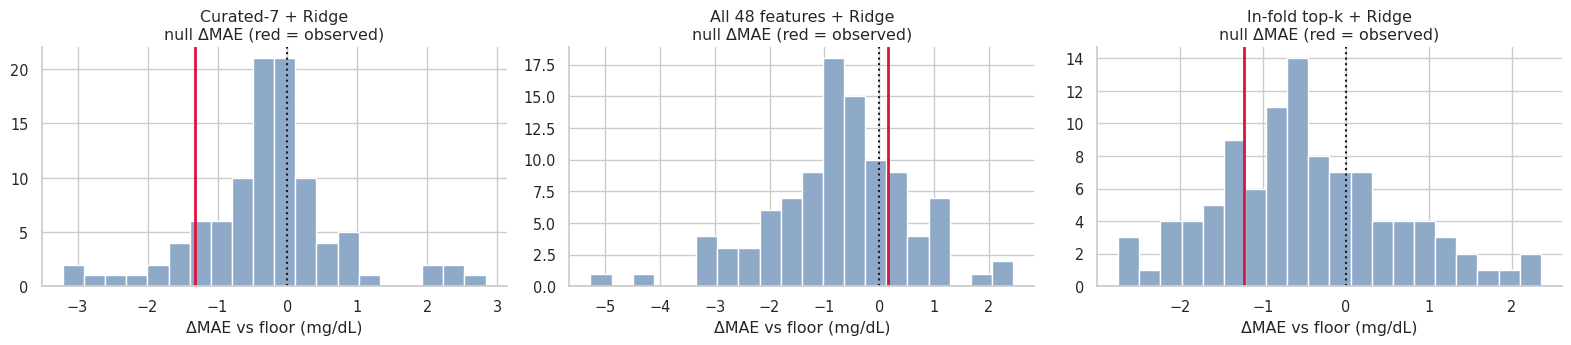

In [5]:
# Permutation null (shuffle BGL within condition, re-run the whole pipeline, 1 repeat per permutation)
def perm_null(Dx, kind, cols, n_perm=N_PERM, seed=SEED, select=None):
    """select: optional callable(y_perm) -> list of feature names (used to mimic 'peeking' selection on the full data)."""
    r = np.random.default_rng(seed); out = []; pp = Dx.pp.values
    for b in range(n_perm):
        yp = Dx.bgl.values.copy()
        for c in (0, 1): ix = np.where(pp == c)[0]; yp[ix] = yp[r.permutation(ix)]
        cc = cols if select is None else select(yp)
        res = cv_oof(Dx, kind, cc, n_rep=1, y=yp, seed=SEED + 1000 + b); o, f = res[0]; out.append(np.abs(yp - f).mean() - np.abs(yp - o).mean())
    return np.array(out)

NULLS = {}; t0 = time.time()
for nm in ["Curated-7 + Ridge", "All 48 features + Ridge", "In-fold top-k + Ridge"]:
    kind, cols = SPECS[nm]; NULLS[nm] = perm_null(S, kind, cols); print(nm, f"null done ({time.time()-t0:.0f}s)")
rows = []
for nm, nl in NULLS.items():
    obs = TAB_AB.loc[nm, "dMAE_vs_floor"]; rows.append(dict(model=nm, observed_dMAE=obs, null_mean=nl.mean(), null_95th_pct=np.quantile(nl, .95), permutation_p=(1 + (nl >= obs).sum()) / (1 + len(nl))))
PERM_TAB = pd.DataFrame(rows).set_index("model"); display(PERM_TAB)

fig, axs = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, (nm, nl) in zip(axs, NULLS.items()):
    ax.hist(nl, bins=20, color="#8fa9c9"); ax.axvline(TAB_AB.loc[nm, "dMAE_vs_floor"], color="crimson", lw=2); ax.axvline(0, color="k", ls=":")
    ax.set(title=f"{nm}\nnull ΔMAE (red = observed)", xlabel="ΔMAE vs floor (mg/dL)")
plt.tight_layout(); plt.show()

## 4. Which features do the in-fold selectors keep?
Selection stability across folds/repeats indicates whether a stable, reproducible predictor set exists (a selector that keeps a different set every time is fitting noise).

In [6]:
from collections import Counter
cnt = Counter(); _ = cv_oof(S, "topk", FEATS, n_rep=5, sel_counter=cnt); nfits = 5 * 5
sel_freq = pd.Series(cnt).sort_values(ascending=False) / nfits
display(sel_freq.head(12).to_frame("share of training folds selecting the feature"))
print(f"features ever selected: {len(sel_freq)} of {len(FEATS)} | selected in more than half of the {nfits} training folds: {int((sel_freq > .5).sum())}")

,share of training folds selecting the feature
spec_flatness,0.640
hf_power,0.520
ac_over_dc_pct,0.520
pw25,0.480
ac_amp_counts,0.440
sd1,0.440
rmssd,0.440
apg_d_a,0.360
total_power_lfhf,0.320
apg_b_a,0.280


features ever selected: 18 of 48 | selected in more than half of the 25 training folds: 3


## 5. Selection bias made visible: "based on the analysis" done the wrong way vs the right way
Here the features are chosen from the correlation with BGL **computed on all 48 recordings (including the ones later used for testing)** — exactly what happens if a pipeline is "built from the EDA results". Both are compared with the honest in-fold selector, and — crucially — with the null distribution of the *same peeking procedure* on
shuffled BGL (the procedure is repeated inside every permutation: select on the full shuffled data, then cross-validate). That null tells us how large a "gain" peeking produces from pure chance.

In [7]:
def top_feats(Dx, y, k):
    r = {f: abs(st.spearmanr(Dx.loc[Dx[f].notna(), f], y[Dx[f].notna().values])[0]) for f in FEATS if Dx[f].notna().sum() >= 20 and Dx[f].nunique() > 3}
    return sorted(r, key=r.get, reverse=True)[:k]
peek5 = top_feats(S, S.bgl.values, 5); peek1 = top_feats(S, S.bgl.values, 1)
print("features selected by peeking at all 48 recordings:", peek5)
PEEK_SPECS = {"PEEKED top-5 + Ridge (biased)": ("ridge", peek5), f"PEEKED best single feature ({peek1[0]}) (biased)": ("ridge", peek1), "In-fold top-k + Ridge (honest)": ("topk", FEATS)}
TAB_PEEK, STORE_PEEK = evaluate(S, PEEK_SPECS, verbose=False)
NULLS_PEEK = {"PEEKED top-5 + Ridge (biased)": perm_null(S, "ridge", None, select=lambda yp: top_feats(S, yp, 5)),
              f"PEEKED best single feature ({peek1[0]}) (biased)": perm_null(S, "ridge", None, select=lambda yp: top_feats(S, yp, 1))}
rows = []
for nm in PEEK_SPECS:
    obs = TAB_PEEK.loc[nm, "dMAE_vs_floor"]; nl = NULLS_PEEK.get(nm)
    rows.append(dict(model=nm, MAE=TAB_PEEK.loc[nm, "MAE"], R2=TAB_PEEK.loc[nm, "R2"], dMAE_vs_floor=obs, CI95_lo=TAB_PEEK.loc[nm, "CI95_lo"], CI95_hi=TAB_PEEK.loc[nm, "CI95_hi"],
                     peeking_null_mean_dMAE=nl.mean() if nl is not None else np.nan, peeking_null_95th=np.quantile(nl, .95) if nl is not None else np.nan, p_vs_peeking_null=(1 + (nl >= obs).sum()) / (1 + len(nl)) if nl is not None else np.nan))
PEEK_TAB = pd.DataFrame(rows).set_index("model"); display(PEEK_TAB)

features selected by peeking at all 48 recordings: ['apg_d_a', 'rmssd', 'sd1', 'total_power_lfhf', 'sdnn']


,MAE,R2,dMAE_vs_floor,CI95_lo,CI95_hi,peeking_null_mean_dMAE,peeking_null_95th,p_vs_peeking_null
model,,,,,,,,
PEEKED top-5 + Ridge (biased),33.216,0.285,1.594,-1.680,4.676,0.365,2.541,0.129
PEEKED best single feature (apg_d_a) (biased),31.442,0.306,3.369,1.023,6.249,0.513,2.901,0.020
In-fold top-k + Ridge (honest),36.036,0.184,-1.225,-4.808,2.024,NaN,NaN,NaN


## 6. Robustness: leave-one-day-out, subgroups, calibration

recordings per day in S_AB: {'2026-08-06': 2, '2026-08-27': 18, '2026-09-03': 20, '2026-09-17': 8}


,n_evaluated,MAE_model,MAE_floor,dMAE
model,,,,
Curated-7 + Ridge,48,40.417,36.820,-3.597
All 48 features + Ridge,48,37.868,36.820,-1.047
In-fold top-k + Ridge,48,41.828,36.820,-5.008


subgroup,fasting,post-prandial,tier A (SQI>=0.7),tier B (0.4-0.7)
model,,,,
All 48 features + PLS,-3.100,2.810,1.060,-1.590
All 48 features + Ridge,-0.690,1.060,-0.190,0.490
All 48 features + shallow RF,-2.520,1.050,1.450,-3.070
Curated-7 + Ridge,-2.500,-0.030,-2.410,-0.220
In-fold top-k + Ridge,-2.180,-0.190,-2.860,0.410


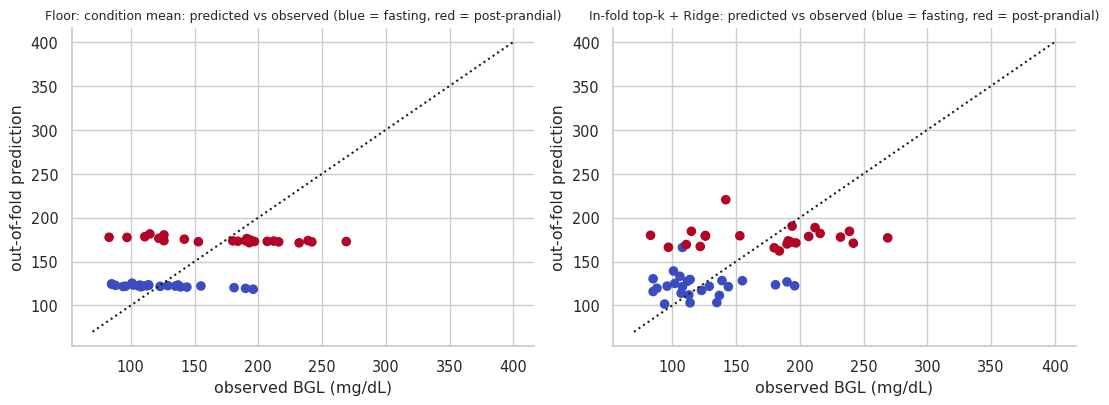

In [8]:
def lodo(Dx, kind, cols):
    y = Dx.bgl.values; pp = Dx.pp.values; g = Dx.participant_id.values; X = Dx[cols].values.astype(float); days = Dx.date.values
    pred = np.full(len(Dx), np.nan); floor = np.full(len(Dx), np.nan)
    for d in np.unique(days):
        te = np.where(days == d)[0]; tr = np.where((days != d) & (~np.isin(g, g[te])))[0]        # also remove participants that appear in the test day
        if len(tr) < 15 or len(te) < 2: continue
        pred[te] = fit_predict(X, y, pp, g, tr, te, kind); floor[te] = cond_mean(y, pp, tr, te)
    ok = ~np.isnan(pred); return y[ok], pred[ok], floor[ok], days[ok]
print("recordings per day in S_AB:", S.date.value_counts().sort_index().to_dict())
rows = []
for nm in ["Curated-7 + Ridge", "All 48 features + Ridge", "In-fold top-k + Ridge"]:
    yy, pr, fl, dd = lodo(S, *SPECS[nm]); rows.append(dict(model=nm, n_evaluated=len(yy), MAE_model=np.abs(yy - pr).mean(), MAE_floor=np.abs(yy - fl).mean(), dMAE=np.abs(yy - fl).mean() - np.abs(yy - pr).mean()))
LODO_TAB = pd.DataFrame(rows).set_index("model"); display(LODO_TAB)

# subgroup view from the repeated-CV predictions (mean over repeats of the per-recording absolute errors)
y = S.bgl.values; sub_rows = []
for nm, res in STORE_AB.items():
    e_m = np.mean([np.abs(y - o) for o, f in res], 0); e_f = np.mean([np.abs(y - f) for o, f in res], 0)
    for lab, mask in [("fasting", S.pp == 0), ("post-prandial", S.pp == 1), ("tier A (SQI>=0.7)", S.tier == "A"), ("tier B (0.4-0.7)", S.tier == "B")]:
        sub_rows.append(dict(model=nm, subgroup=lab, n=int(mask.sum()), MAE_model=e_m[mask].mean(), MAE_floor=e_f[mask].mean(), dMAE=e_f[mask].mean() - e_m[mask].mean()))
SUB = pd.DataFrame(sub_rows); display(SUB.pivot(index="model", columns="subgroup", values="dMAE").round(2))

# predicted vs observed for the honest nested selector (prediction averaged over repeats: for display only)
res = STORE_AB["In-fold top-k + Ridge"]; pm = np.mean([o for o, f in res], 0); fm = np.mean([f for o, f in res], 0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, p, t in zip(ax, [fm, pm], ["Floor: condition mean", "In-fold top-k + Ridge"]):
    a.scatter(S.bgl, p, c=S.pp, cmap="coolwarm", s=35); a.plot([70, 400], [70, 400], "k:"); a.set(title=f"{t}: predicted vs observed (blue = fasting, red = post-prandial)", xlabel="observed BGL (mg/dL)", ylabel="out-of-fold prediction"); a.title.set_fontsize(9)
plt.tight_layout(); plt.show()

## 7. Context: the same pipelines on all 100 recordings (no quality filter)
This shows what happens if the quality of the pulse is ignored (what a model would see if every recording were used as-is).

In [9]:
TAB_ALL, STORE_ALL = evaluate(A, SPECS, n_rep=5, verbose=False); display(TAB_ALL)
yA = A.bgl.values; rows = []
for nm in ["Curated-7 + Ridge", "In-fold top-k + Ridge"]:
    res = STORE_ALL[nm]; e_m = np.mean([np.abs(yA - o) for o, f in res], 0); e_f = np.mean([np.abs(yA - f) for o, f in res], 0)
    for t in ["A", "B", "C"]: m = (A.tier == t).values; rows.append(dict(model=nm, tier=t, n=int(m.sum()), MAE_model=e_m[m].mean(), MAE_floor=e_f[m].mean(), dMAE=e_f[m].mean() - e_m[m].mean()))
display(pd.DataFrame(rows).pivot(index="model", columns="tier", values="dMAE").round(2))

,MAE,RMSE,R2,dMAE_vs_floor,CI95_lo,CI95_hi,share_repeats_better
model,,,,,,,
FLOOR: global mean,46.955,61.635,-0.026,NaN,NaN,NaN,NaN
FLOOR: condition mean (is_postprandial only),40.546,58.096,0.088,NaN,NaN,NaN,NaN
Curated-7 + Ridge,40.932,58.816,0.066,-0.386,-0.705,-0.109,0.000
All 48 features + Ridge,40.737,59.079,0.057,-0.191,-1.585,1.071,0.200
All 48 features + PLS,43.037,63.704,-0.097,-2.491,-5.795,0.607,0.200
In-fold top-k + Ridge,40.276,59.147,0.055,0.270,-1.071,1.593,0.800
All 48 features + shallow RF,42.775,61.613,-0.025,-2.229,-4.659,0.218,0.000


tier,A,B,C
model,,,
Curated-7 + Ridge,-0.400,-0.220,-0.450
In-fold top-k + Ridge,1.300,1.260,-0.670


### 6b. Is the one surviving candidate (`apg_d_a`) consistent across days, conditions and tiers? (descriptive)
Section 5 leaves one feature whose gain exceeds what selection-by-peeking produces by chance. Before reading anything into it we check that its association with BGL (after removing the fasting/post-prandial offset) does not come from a single day, condition or quality tier, or from age/diabetes duration. **n = 33 recordings have a detectable *d* wave**, so these are small-sample descriptives.

In [10]:
S["res"] = S.bgl - S.groupby("pp").bgl.transform("mean"); d = S.dropna(subset=["apg_d_a"])
print(f"recordings with a detectable d wave: {len(d)} of {len(S)} | Spearman(apg_d_a, BGL) = {st.spearmanr(d.apg_d_a, d.bgl)[0]:.2f} | vs condition-adjusted BGL = {st.spearmanr(d.apg_d_a, d.res)[0]:.2f}")
rows = []
for lab, key in [("day", "date"), ("condition", "pp"), ("tier", "tier")]:
    for k, g in d.groupby(key):
        if len(g) >= 6: rows.append(dict(split=lab, level=str(k), n=len(g), rho_with_condition_adjusted_BGL=st.spearmanr(g.apg_d_a, g.res)[0]))
display(pd.DataFrame(rows))
print("Spearman(apg_d_a, age) = %.2f | Spearman(apg_d_a, years on T2DM) = %.2f | is the d wave being detectable related to BGL? MWU p = %.2f" %
      (st.spearmanr(d.apg_d_a, d.age)[0], st.spearmanr(d.apg_d_a, d.years_on_t2dm)[0], st.mannwhitneyu(S.res[S.apg_d_a.notna()], S.res[S.apg_d_a.isna()])[1]))

recordings with a detectable d wave: 33 of 48 | Spearman(apg_d_a, BGL) = 0.53 | vs condition-adjusted BGL = 0.52


,split,level,n,rho_with_condition_adjusted_BGL
0,day,2026-08-27,13,0.495
1,day,2026-09-03,15,0.643
2,condition,0,19,0.403
3,condition,1,14,0.666
4,tier,B,18,0.408
5,tier,A,15,0.296


Spearman(apg_d_a, age) = -0.08 | Spearman(apg_d_a, years on T2DM) = -0.10 | is the d wave being detectable related to BGL? MWU p = 0.40


## 8. What the pipelines say

**Results (S_AB, n = 48, 43 participants; MAE in mg/dL).**

1. **The floor is not trivial.** Predicting the global mean gives MAE 43.3 (R² ≈ −0.04); adding only `is_postprandial` gives **MAE 34.8, R² ≈ 0.22**. Everything below is measured against that.
2. **No honest PPG pipeline beats the floor.** ΔMAE (floor − model) is −1.3 (curated-7 Ridge), +0.15 (all-48 Ridge), −0.3 (PLS), −1.2 (in-fold top-k + Ridge), −0.8 (shallow random forest); all bootstrap CIs include 0, and permutation p-values are 0.88 (curated), 0.23 (all-48 Ridge) and 0.74 (top-k). The regularised models mostly return the floor plus noise.
3. **There is no stable, automatically discoverable predictor set at this n.** The in-fold selector picked 18 of the 48 features across training folds and only three (`spec_flatness`, `hf_power`, `ac_over_dc_pct`) in more than half of them — the ranking of features by |ρ| is not reproducible from one training subset to the next.
4. **Peeking inflates apparent skill.** Choosing the top-5 features on all 48 recordings gives ΔMAE +1.6 (R² 0.29) versus −1.2 for the honest in-fold version — about **3 mg/dL of "improvement" that comes only from having looked** (its peeking-null mean is +0.4 and its p-value against that null is 0.13, i.e. not distinguishable from chance). *This* is the trap to avoid when building a model "from the EDA".
5. **One candidate survives the peeking-corrected test: `apg_d_a`** (ratio of the second-derivative *d* wave to the *a* wave). A one-feature model gives ΔMAE **+3.4** (CI +1.0 to +6.2; R² 0.31 vs 0.22) and beats the *peeking null* (null mean +0.5, 95th percentile +2.9; p = 0.02). Section 6b: its association has the same sign on both large days (ρ ≈ +0.50, +0.64), in both conditions (fasting +0.40, post-prandial +0.67) and in both quality tiers (A +0.30, B +0.41), and is unrelated to age or diabetes duration (ρ ≈ −0.1); whether a *d* wave is detectable is itself unrelated to BGL.
   Caveats that keep this a **hypothesis, not a result**: it was highlighted by the EDA on these same recordings (the peeking-null corrects for choosing among 48 features, not for the other analytic choices — quality cut-off, three analysis sets, etc.); only 33 of 48 recordings have a detectable *d* wave (the rest receive the median); the gain (≈ 3 mg/dL) is small relative to reference-meter tolerance (±15 %); and it does not generalise across days in the leave-one-day-out check for the multi-feature models (below).
6. **Cross-day generalisation fails for the multi-feature models.** Leave-one-day-out MAE is worse than the floor for all three (−1.0 to −5.0 mg/dL). Subgroup breakdowns (fasting vs post-prandial, tier A vs B) are inconsistent in sign, i.e. noise.
7. **Ignoring quality does not help either.** On all 100 recordings the floor is MAE 40.5 (R² 0.09) and no model beats it reliably (ΔMAE −2.5 to +0.3; tier-wise differences ≈ 0), consistent with the EDA finding that the ~52 recordings without a periodic pulse carry no usable beat-level information.

**Interpretation.** The machine-learning pipelines *confirm* the EDA rather than rescue it: with 48 recordings, participant-grouped validation and no peeking, PPG-derived features add **no reliable predictive information over the fasting/post-prandial flag**. The single feature with evidence beyond chance selection (`apg_d_a`) is worth a *pre-specified confirmatory test on new data*, not a claim.

**What you can defensibly write in the thesis**
* "A leak-free, participant-grouped evaluation framework was built; PPG features did not improve on the is_postprandial-only baseline (MAE 34.8 mg/dL, R² 0.22 in the clean subset)."
* "An exploratory single-feature signal (APG d/a) was identified whose gain exceeded a selection-corrected null (p = 0.02), consistent across days/conditions, and is proposed for confirmation."
* "Naïve feature selection on the full data inflated apparent gains by ≈ 3 mg/dL — illustrating why grouped, nested validation is required."
* Do **not** report the peeked models or any model trained on all 100 recordings without the floor.

**Suggested next steps (in order of value)**
1. **Confirmatory test of `apg_d_a`:** fix the rule now (SQI ≥ 0.40; APG *d* wave detected; one-feature Ridge on the condition-mean residual; primary metric ΔMAE vs floor, participant-grouped) and apply it to *new* recordings collected with better contact control. With ρ ≈ 0.5 roughly 30–40 new recordings with a detectable *d* wave would be needed to see it, and improving *d*-wave detectability would raise the yield.
2. **Improve the data, not the model:** aim for > 70 % tier-A recordings (Section 11.8 of the EDA), log sensor settings and timestamps, and collect repeat visits per participant so that within-person change (the physiologically meaningful test) becomes estimable.
3. **Design the deployed behaviour around quality:** if SQI < 0.40 (or the *d* wave is not detectable), return the fasting/post-prandial estimate and say so; report accuracy by tier.
4. Only then consider richer learners; at n ≈ 50 they cannot be validated (EDA §10.2).

**Re-using this notebook.** `cv_oof`, `evaluate`, `perm_null` and `lodo` accept any dataframe with `bgl`, `pp`, `participant_id`, `date` and feature columns — replace `FEATS`/`CURATED` (or point `FEATURE_CACHE` to your own feature table) and re-run.